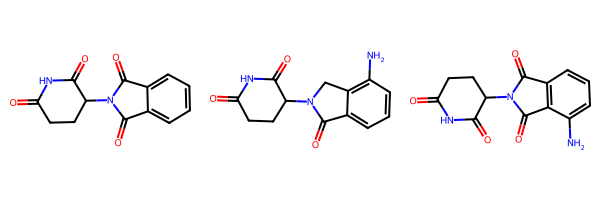

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
smiles = ['O=C1NC(=O)C(N2C(=O)C=3C=CC=CC3C2=O)CC1', 'O=C1NC(=O)C(N2C(=O)C=3C=CC=C(N)C3C2)CC1', 'O=C1CCC(C(=O)N1)N1C(=O)c2c(C1=O)c(N)ccc2']
mols = [Chem.MolFromSmiles(s) for s in smiles]
Draw.MolsToGridImage(mols, molsPerRow=3)

In [2]:
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
import pandas as pd

for mol in mols:
    adj_matrix = GetAdjacencyMatrix(mol)
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    df_adj = pd.DataFrame(adj_matrix, index=atoms, columns=atoms)
    print("\n--- Adjacency Matrix (Pandas DataFrame with Atom Symbols) ---")
    print(df_adj)



--- Adjacency Matrix (Pandas DataFrame with Atom Symbols) ---
   O  C  N  C  O  C  N  C  O  C  C  C  C  C  C  C  O  C  C
O  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
C  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
N  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
C  0  0  1  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0
O  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
C  0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  1  0
N  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  0  0  0
C  0  0  0  0  0  0  1  0  1  1  0  0  0  0  0  0  0  0  0
O  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0
C  0  0  0  0  0  0  0  1  0  0  1  0  0  0  1  0  0  0  0
C  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0
C  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  0
C  0  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0
C  0  0  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0
C  0  0  0  0  0  0  0  0  0  1  0  0  0  1  0  1  0

In [4]:
import deepchem.feat.molecule_featurizers.mol_graph_conv_featurizer as mgcf
canonical_smiles = [Chem.MolToSmiles(mol) for mol in mols]
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=True)
out = featurizer.featurize(canonical_smiles)
out

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
/home/haolan/anaconda3/envs/deepchem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading some PyTorch models, missing a dependency. No module named 'transformers'
No module named 'transformers'
Skipped loading modules with pytorc

array([GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=[42, 11]),
       GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=[42, 11]),
       GraphData(node_features=[20, 30], edge_index=[2, 44], edge_features=[44, 11])],
      dtype=object)

In [5]:
canonical_smiles = [Chem.MolToSmiles(mol) for mol in mols]
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
out = featurizer.featurize(canonical_smiles)
out

array([GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=None),
       GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=None),
       GraphData(node_features=[20, 30], edge_index=[2, 44], edge_features=None)],
      dtype=object)